In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import plotly.express as px

In [2]:
df = pd.read_csv('../data/cohort/cohort_analysis.csv',
                 parse_dates = ["acquisition_date", 'cancellation_month'],
                 #errors = "coerce"
                 )
df.head()

,user_id,acquisition_date,cancellation_month,gender,marital_status,age,income_segment,country,channel,campaign_id,device_type,plan_type
0,1,2024-07-01,2025-02-01,Male,Married,31,Medium,Germany,Paid Ads,Paid Ads_C,iOS,Standard
1,2,2024-04-01,2024-05-01,Male,Single,54,Premium,Netherlands,Referral,Referral_B,iOS,Standard
2,3,2024-05-01,2024-07-01,Male,Single,34,Medium,Poland,Paid Ads,Paid Ads_A,Android,Standard
3,4,2024-07-01,NaT,Male,Married,38,High,Belgium,Organic,Organic_C,Android,Standard
4,5,2024-03-01,2024-04-01,Male,Single,25,Low,Sweden,Paid Ads,Paid Ads_A,Android,Basic


errors = "coerce" wasn't working, then use chatGPT solution :D

In [3]:
df = pd.read_csv("../data/cohort/cohort_analysis.csv")

df["acquisition_date"] = pd.to_datetime(
    df["acquisition_date"],
    errors="coerce"
)

df["cancellation_month"] = pd.to_datetime(
    df["cancellation_month"],
    errors="coerce"
)
df.head()

,user_id,acquisition_date,cancellation_month,gender,marital_status,age,income_segment,country,channel,campaign_id,device_type,plan_type
0,1,2024-07-01,2025-02-01,Male,Married,31,Medium,Germany,Paid Ads,Paid Ads_C,iOS,Standard
1,2,2024-04-01,2024-05-01,Male,Single,54,Premium,Netherlands,Referral,Referral_B,iOS,Standard
2,3,2024-05-01,2024-07-01,Male,Single,34,Medium,Poland,Paid Ads,Paid Ads_A,Android,Standard
3,4,2024-07-01,NaT,Male,Married,38,High,Belgium,Organic,Organic_C,Android,Standard
4,5,2024-03-01,2024-04-01,Male,Single,25,Low,Sweden,Paid Ads,Paid Ads_A,Android,Basic


In [4]:
df.shape

(12000, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   user_id             12000 non-null  int64         
 1   acquisition_date    12000 non-null  datetime64[us]
 2   cancellation_month  7066 non-null   datetime64[us]
 3   gender              12000 non-null  str           
 4   marital_status      12000 non-null  str           
 5   age                 12000 non-null  int64         
 6   income_segment      11369 non-null  str           
 7   country             12000 non-null  str           
 8   channel             12000 non-null  str           
 9   campaign_id         12000 non-null  str           
 10  device_type         12000 non-null  str           
 11  plan_type           12000 non-null  str           
dtypes: datetime64[us](2), int64(2), str(8)
memory usage: 1.7 MB


In [6]:
#Missing values:
df.isnull().sum()

user_id                  0
acquisition_date         0
cancellation_month    4934
gender                   0
marital_status           0
age                      0
income_segment         631
country                  0
channel                  0
campaign_id              0
device_type              0
plan_type                0
dtype: int64

In [7]:
df.describe(include="all")

,user_id,acquisition_date,cancellation_month,gender,marital_status,age,income_segment,country,channel,campaign_id,device_type,plan_type
count,12000.00000,12000,7066,12000,12000,12000.000000,11369,12000,12000,12000,12000,12000
unique,NaN,NaN,NaN,2,2,NaN,4,12,3,9,3,3
top,NaN,NaN,NaN,Female,Single,NaN,High,Netherlands,Paid Ads,Paid Ads_A,Android,Standard
freq,NaN,NaN,NaN,6016,7087,NaN,4823,1057,4854,1636,6582,5979
mean,6000.50000,2024-04-15 20:46:48,2024-07-28 15:31:07.761109,NaN,NaN,34.630250,NaN,NaN,NaN,NaN,NaN,NaN
min,1.00000,2024-01-01 00:00:00,2024-02-01 00:00:00,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,3000.75000,2024-02-01 00:00:00,2024-05-01 00:00:00,NaN,NaN,28.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,6000.50000,2024-04-01 00:00:00,2024-07-01 00:00:00,NaN,NaN,34.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,9000.25000,2024-06-01 00:00:00,2024-10-01 00:00:00,NaN,NaN,41.000000,NaN,NaN,NaN,NaN,NaN,NaN
max,12000.00000,2024-08-01 00:00:00,2025-08-01 00:00:00,NaN,NaN,65.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df["acquisition_month"] = df["acquisition_date"].dt.to_period("M")

df[["user_id", "acquisition_date", "acquisition_month"]].head()

,user_id,acquisition_date,acquisition_month
0,1,2024-07-01,2024-07
1,2,2024-04-01,2024-04
2,3,2024-05-01,2024-05
3,4,2024-07-01,2024-07
4,5,2024-03-01,2024-03


Visualization

<Axes: title={'center': 'Gender Distribution'}, xlabel='gender'>

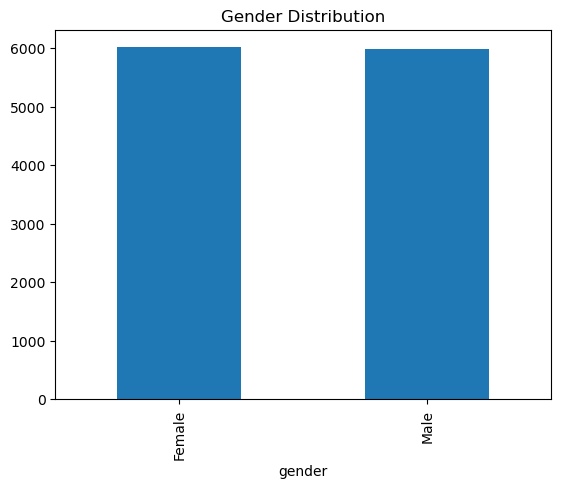

In [9]:
df["gender"].value_counts().plot(kind="bar", title="Gender Distribution")

<Axes: title={'center': 'Marital Status Distribution'}, xlabel='marital_status'>

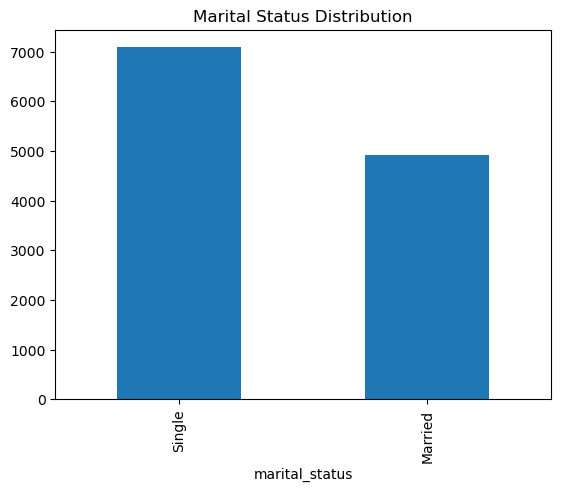

In [10]:
df["marital_status"].value_counts().plot(kind="bar", title="Marital Status Distribution")

<Axes: title={'center': 'Age Distribution'}, ylabel='Frequency'>

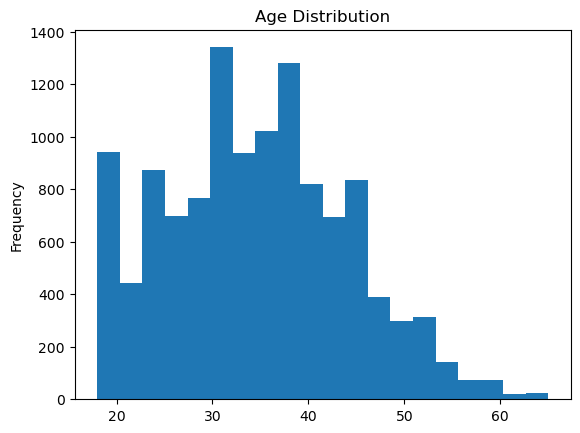

In [11]:
df["age"].plot(kind="hist", bins=20, title="Age Distribution")

<Axes: title={'center': 'Country Distribution'}, xlabel='country'>

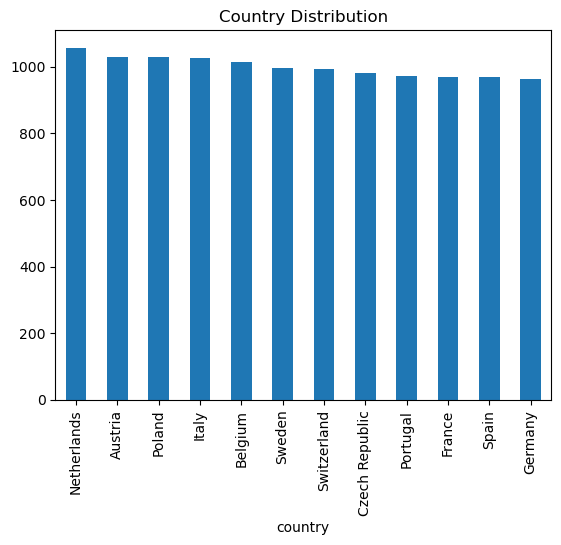

In [12]:
df["country"].value_counts().plot(kind="bar", title="Country Distribution")

<Axes: title={'center': 'Channel Distribution'}, xlabel='channel'>

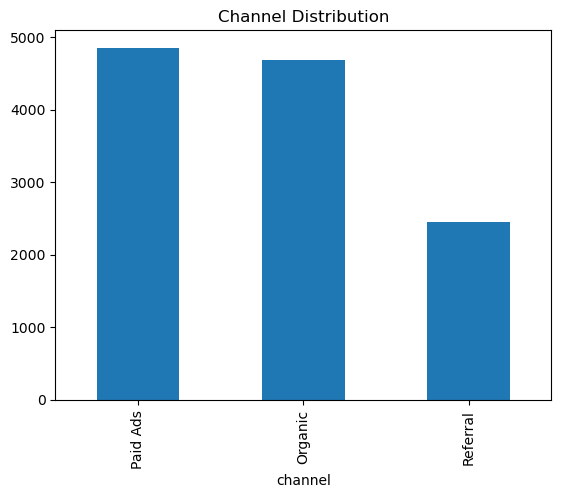

In [13]:
df["channel"].value_counts().plot(kind="bar", title="Channel Distribution")

<Axes: title={'center': 'Plan Type Distribution'}, xlabel='plan_type'>

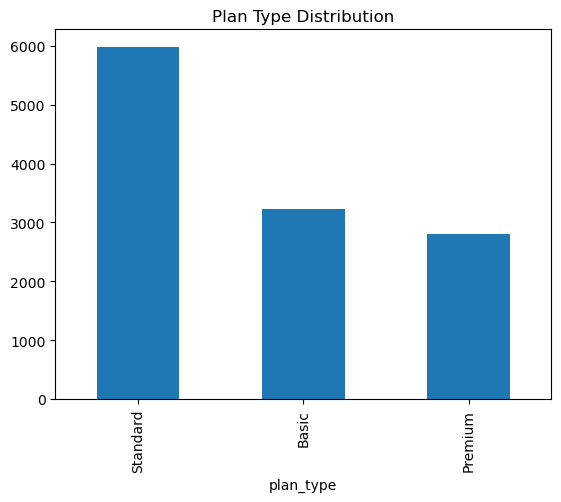

In [14]:
df["plan_type"].value_counts().plot(kind="bar", title="Plan Type Distribution")

In [15]:
cohort_size = df.groupby("acquisition_month")["user_id"].nunique()
cohort_size

acquisition_month
2024-01    1502
2024-02    1528
2024-03    1465
2024-04    1509
2024-05    1541
2024-06    1493
2024-07    1500
2024-08    1462
Freq: M, Name: user_id, dtype: int64

In [16]:
cohort_size = df.groupby("acquisition_month")["user_id"].size()
cohort_size
#same as above

acquisition_month
2024-01    1502
2024-02    1528
2024-03    1465
2024-04    1509
2024-05    1541
2024-06    1493
2024-07    1500
2024-08    1462
Freq: M, Name: user_id, dtype: int64

<Axes: title={'center': 'Cohort Size by Acquisition Month'}, xlabel='acquisition_month'>

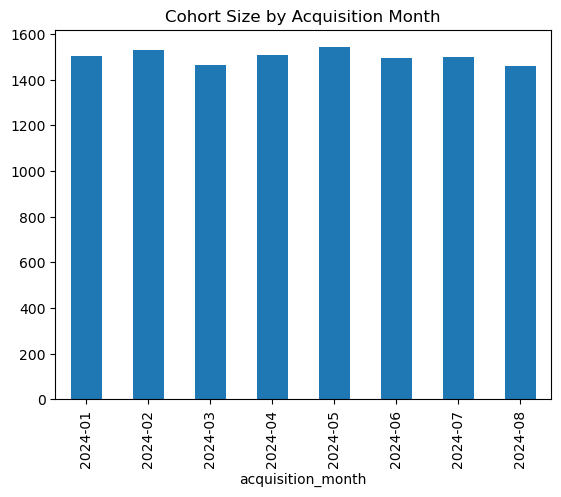

In [17]:
cohort_size.plot(kind="bar",
                 title="Cohort Size by Acquisition Month")

<Axes: title={'center': 'Gender Composition by Cohort'}, xlabel='acquisition_month'>

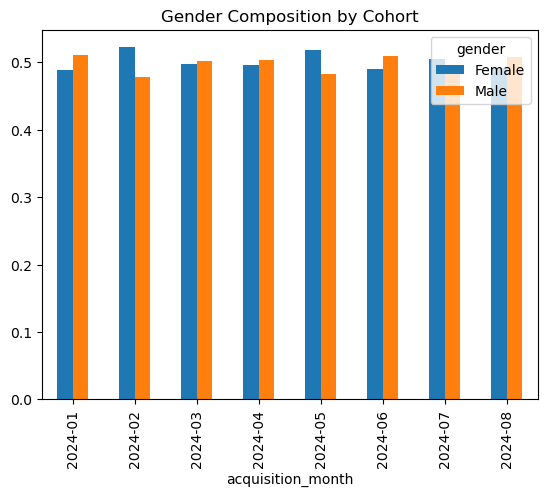

In [18]:
gender_cohort = (
    df.groupby(["acquisition_month", "gender"])["user_id"]
    .nunique()
    .unstack()
)

gender_cohort.div(gender_cohort.sum(axis=1), axis=0).plot(
    kind="bar",
    stacked=False,
    title="Gender Composition by Cohort"
)

In [19]:
df[['user_id', 'acquisition_date', 'acquisition_month', 'cancellation_month']].head()

,user_id,acquisition_date,acquisition_month,cancellation_month
0,1,2024-07-01,2024-07,2025-02-01
1,2,2024-04-01,2024-04,2024-05-01
2,3,2024-05-01,2024-05,2024-07-01
3,4,2024-07-01,2024-07,NaT
4,5,2024-03-01,2024-03,2024-04-01


In [20]:
cohort_size = (
    df.groupby("acquisition_month")
    .agg(new_users=("user_id", "count"))
    .reset_index()
)
cohort_size

,acquisition_month,new_users
0,2024-01,1502
1,2024-02,1528
2,2024-03,1465
3,2024-04,1509
4,2024-05,1541
5,2024-06,1493
6,2024-07,1500
7,2024-08,1462


In [21]:
from utils import my_date_diff
df = my_date_diff(df=df,
                  target_column='month_churned',
                  start_date='acquisition_month',
                  end_date='cancellation_month'
                  )
df.head()

,user_id,acquisition_date,cancellation_month,gender,marital_status,age,income_segment,country,channel,campaign_id,device_type,plan_type,acquisition_month,month_churned
0,1,2024-07-01,2025-02-01,Male,Married,31,Medium,Germany,Paid Ads,Paid Ads_C,iOS,Standard,2024-07,7.0
1,2,2024-04-01,2024-05-01,Male,Single,54,Premium,Netherlands,Referral,Referral_B,iOS,Standard,2024-04,1.0
2,3,2024-05-01,2024-07-01,Male,Single,34,Medium,Poland,Paid Ads,Paid Ads_A,Android,Standard,2024-05,2.0
3,4,2024-07-01,NaT,Male,Married,38,High,Belgium,Organic,Organic_C,Android,Standard,2024-07,NaN
4,5,2024-03-01,2024-04-01,Male,Single,25,Low,Sweden,Paid Ads,Paid Ads_A,Android,Basic,2024-03,1.0
